### Задача

Написать многоклассовый классификатор на датасете Спрингфилд. Обучить на GPU свою архитектуру и дообучить предобученную архитектуру (Fine-Tuning).
Продемонтсрировать результаты

In [1]:
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

### Установка зависимостей 
Установим ROCm GPU:

!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/rocm6.4

!   
export HSA_OVERRIDE_GFX_VERSION=10.3.0

In [1]:
import torch

torch.cuda.is_available()

True

Если не сработало, то просто рестартни юпитер ядро

In [3]:
import numpy as np

from tqdm import tqdm
from PIL import Image
from pathlib import Path

from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

import matplotlib.pyplot as plt

In [4]:
DATA_MODES = ['train', 'val', 'test']
RESCALE_SIZE = 224
DEVICE = torch.device("cuda")

`torch.utils.data.Dataset` - это абстрактный класс, от него наследуем свой класс, одно правило - определены `__len__` и `__getitem__`.

In [5]:
TRAIN_DIR = Path('./journey-springfield/train/')
TEST_DIR = Path('./journey-springfield/testset')

In [6]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg'))) # .rglob('шаблон_поиска')-> Generator[Path]: рекурсивыный поиск путей по шаблону -> возвращает генератор
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

In [7]:
le = LabelEncoder()
train_val_labels = [path.parent.name for path in train_val_files]
train_val_labels = le.fit_transform(train_val_labels)

In [8]:
train_files, val_files, train_labels, val_labels = train_test_split(train_val_files, train_val_labels, test_size=0.25, stratify=train_val_labels)

In [9]:
class MyDataset(Dataset):
    def __init__(self, paths, transform=None, le=None, anamal_labels=None):
        super().__init__()
        self.paths = paths
        self.transform = transform
        self.le = le
        self.anamal_labels = anamal_labels

        if self.anamal_labels is not None:
            self.anamal_transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
            ])
    
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image = Image.open(self.paths[index])
        X = np.array(image)
        if self.transform:
            X = self.transform(X)

        if self.le is None: raise Exception('No LabelEncoder here...')

        y = self.paths[index].parent.name
        if (self.anamal_labels is not None) and (y in self.anamal_labels):
            X = self.anamal_transform(X)

        y = self.le.transform([y])[0]
        return X, y       

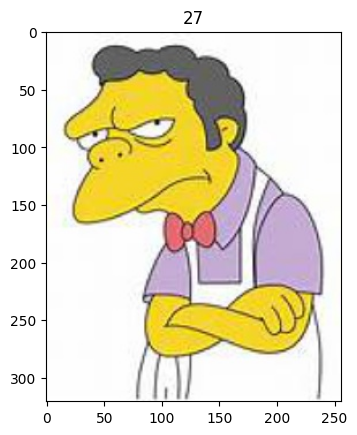

In [10]:
kop = MyDataset(train_files, le=le)
plt.imshow(kop[0][0])
plt.title(kop[0][1])
plt.show()

Посмотрим на распределения классов и увидим сильный дисбаланс

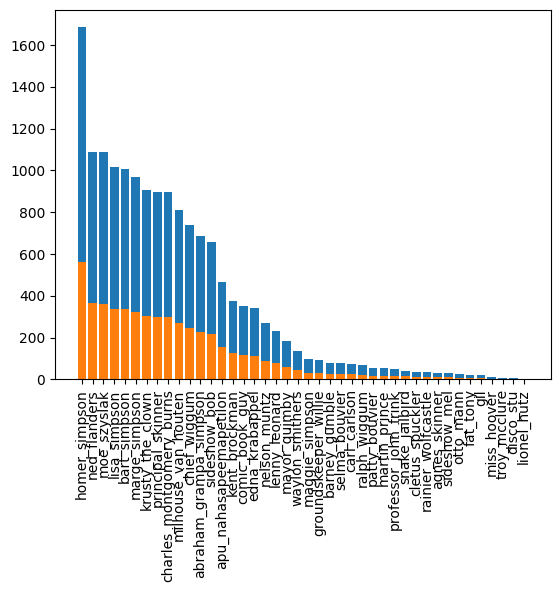

In [11]:
import pandas  as pd
tr_l = pd.Series(le.inverse_transform(train_labels)).value_counts()
va_l = pd.Series(le.inverse_transform(val_labels)).value_counts()
plt.bar(tr_l.index, tr_l)
plt.bar(va_l.index, va_l)
plt.xticks(rotation=90)
plt.show()

Предлагаю провести аугментацию на редких классах, чтобы поправить дисбаланс

In [12]:
anamal_labels = tr_l[tr_l < 300].index
anamal_labels

Index(['nelson_muntz', 'lenny_leonard', 'mayor_quimby', 'waylon_smithers',
       'maggie_simpson', 'groundskeeper_willie', 'barney_gumble',
       'selma_bouvier', 'carl_carlson', 'ralph_wiggum', 'patty_bouvier',
       'martin_prince', 'professor_john_frink', 'snake_jailbird',
       'cletus_spuckler', 'rainier_wolfcastle', 'agnes_skinner',
       'sideshow_mel', 'otto_mann', 'fat_tony', 'gil', 'miss_hoover',
       'troy_mcclure', 'disco_stu', 'lionel_hutz'],
      dtype='object')

Идея заключается в том, чтобы для аномальных классов применять другой трансформатор

Напомню теорию по Normalize

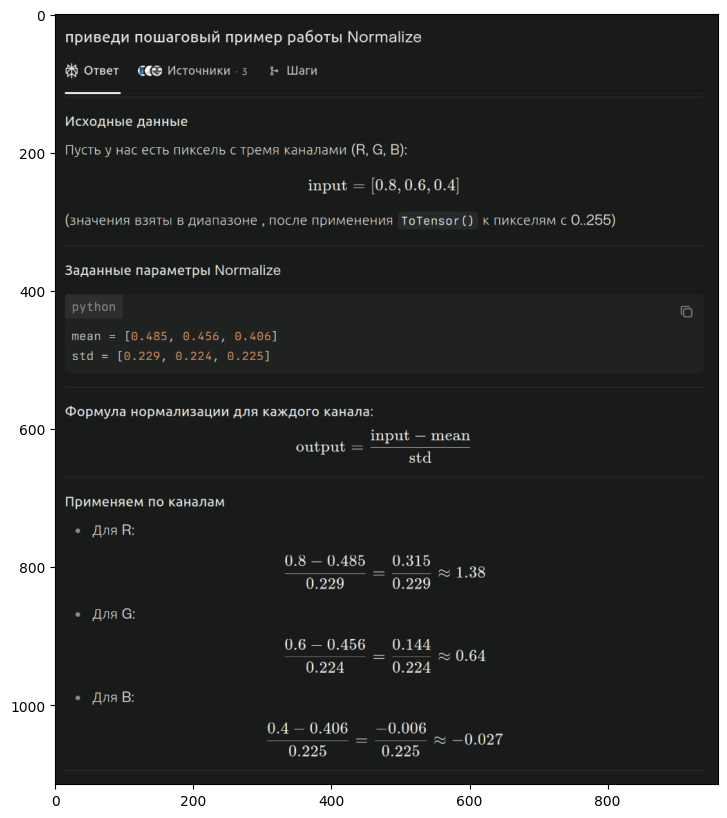

In [13]:
plt.figure(figsize=(10, 10))
plt.imshow(Image.open('screenshot.png'))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.6400006].


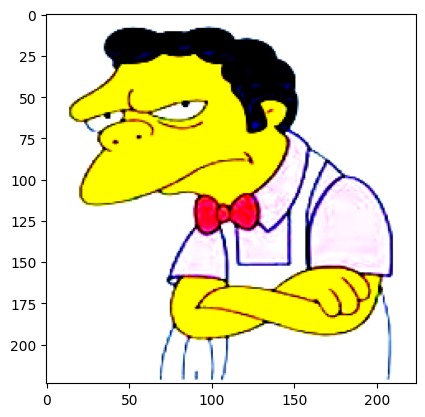

In [63]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((RESCALE_SIZE, RESCALE_SIZE)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# tr_dataset = MyDataset(train_files, transform=transform, le=le, anamal_labels=anamal_labels)
tr_dataset = MyDataset(train_files, transform=transform, le=le, anamal_labels=tr_l.index)
va_dataset = MyDataset(val_files, transform=transform, le=le)

plt.imshow(tr_dataset[0][0].numpy().transpose((1, 2, 0)))

In [113]:
tr_dataloader = DataLoader(tr_dataset, batch_size=8, shuffle=True, num_workers=2)
va_dataloader = DataLoader(va_dataset, batch_size=128, shuffle=False, num_workers=2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.840425..2.0595253].


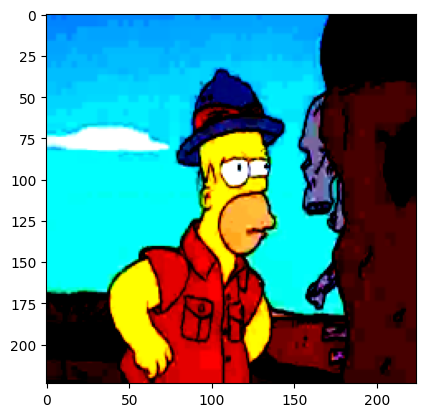

In [16]:
plt.imshow(next(iter(tr_dataloader))[0][0].numpy().transpose(1, 2, 0))

#### Модель

In [17]:
class SimpleCnn(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(8),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

Функции ниже писал не я, что-то немного отредактировал под свои даталоадеры и все

#### Функция обучения:

In [141]:
def fit_epoch(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    processed_data = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_data += inputs.size(0)

    train_loss = running_loss / processed_data
    train_acc = running_corrects.cpu().numpy() / processed_data
    return train_loss, train_acc

#### Функция валидации:

In [19]:
def eval_epoch(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, 1)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_size += inputs.size(0)
    val_loss = running_loss / processed_size
    val_acc = running_corrects.double() / processed_size
    return val_loss, val_acc

#### Полный цикл обучения

In [ ]:
def train(tr_dataloader, va_dataloader, model, epochs, opt=None, criterion=None):
    history = []
    log_template = "\nEpoch {ep:03d} train_loss: {t_loss:0.4f} \
    val_loss {v_loss:0.4f} train_acc {t_acc:0.4f} val_acc {v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        if opt is None: opt = torch.optim.Adam(model.parameters(), lr=3e-4)
        if criterion is None: criterion = nn.CrossEntropyLoss()
        scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=1, gamma=0.5)

        for epoch in range(epochs):
            train_loss, train_acc = fit_epoch(model, tr_dataloader, criterion, opt)
            print("loss", train_loss)

            val_loss, val_acc = eval_epoch(model, va_dataloader, criterion)
            history.append((train_loss, train_acc, val_loss, val_acc))

            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,\
                                           v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))
            scheduler.step()

    return history

#### Применение модели к данным

In [21]:
def predict(model, test_loader):
    with torch.no_grad():
        logits = []

        for inputs in test_loader:
            inputs = inputs.to(DEVICE)
            model.eval()
            outputs = model(inputs).cpu()
            logits.append(outputs)

    probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
    return probs

In [142]:
n_classes = len(np.unique(train_val_labels))
simple_cnn = SimpleCnn(n_classes).to(DEVICE)
print("we will classify :{}".format(n_classes))
print(simple_cnn)

we will classify :42
SimpleCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1,

Запустим обучение сети.

In [143]:
history = train(tr_dataloader, va_dataloader, model=simple_cnn, epochs=6)

epoch:   0%|          | 0/6 [00:00<?, ?it/s]

loss 1.7937928124729772


epoch:  17%|█▋        | 1/6 [00:42<03:33, 42.63s/it]


Epoch 001 train_loss: 1.7938     val_loss 1.1635 train_acc 0.5113 val_acc 0.6836
loss 0.9510308858793824


epoch:  33%|███▎      | 2/6 [01:23<02:46, 41.63s/it]

...


Epoch 004 train_loss: 0.4996     val_loss 0.6937 train_acc 0.8591 val_acc 0.8147
loss 0.3969759052838005


epoch:  83%|████████▎ | 5/6 [03:31<00:42, 42.44s/it]


Epoch 005 train_loss: 0.3970     val_loss 0.6671 train_acc 0.8862 val_acc 0.8332
loss 0.31957546135949205


epoch: 100%|██████████| 6/6 [04:14<00:00, 42.44s/it]


Epoch 006 train_loss: 0.3196     val_loss 0.6681 train_acc 0.9084 val_acc 0.8389


Построим кривые обучения

In [144]:
loss, acc, val_loss, val_acc = zip(*history)

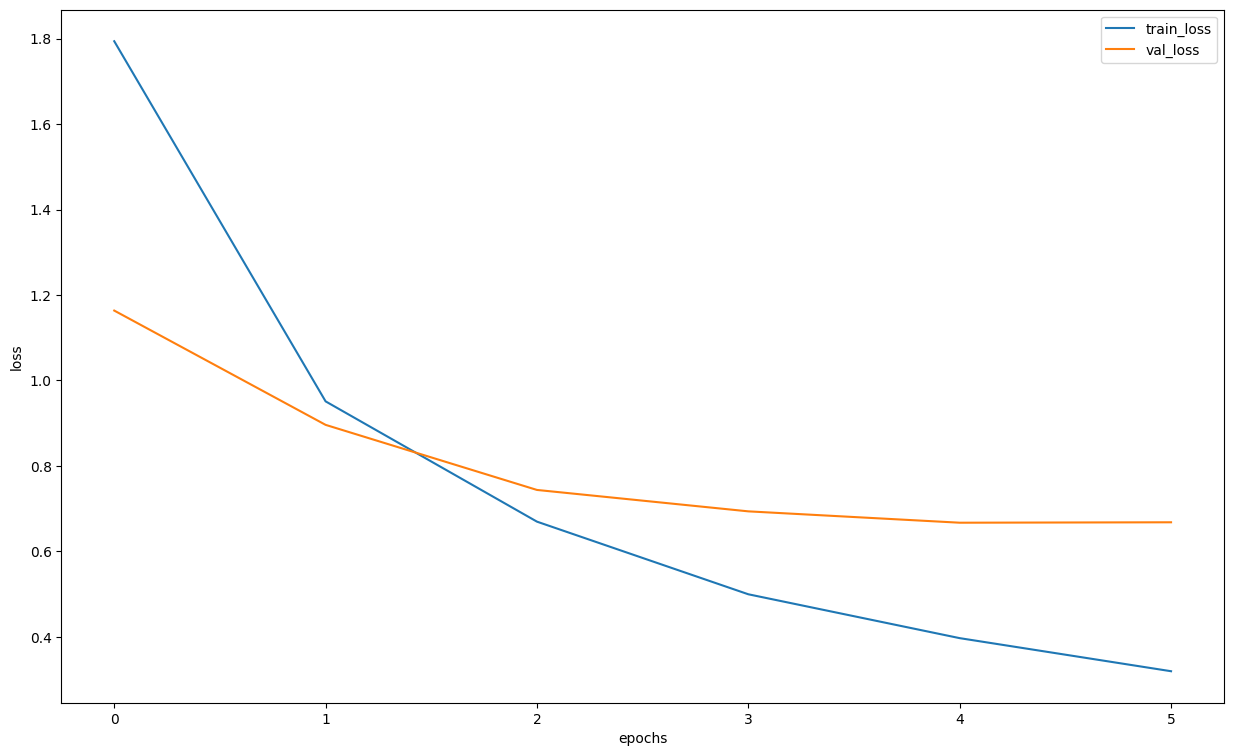

In [145]:
plt.figure(figsize=(15, 9))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

In [146]:
def predict_one_sample(model, inputs, device=DEVICE):
    """Предсказание, для одной картинки"""
    with torch.no_grad():
        inputs = inputs.to(device)
        model.eval()
        logit = model(inputs).cpu()
        probs = torch.nn.functional.softmax(logit, dim=-1).numpy()
    return probs

In [147]:
idxs = range(len(va_dataset))
imgs = [va_dataset[id][0].unsqueeze(0) for id in idxs]
probs_ims = predict(simple_cnn, imgs)

In [148]:
y_pred = np.argmax(probs_ims,-1)
actual_labels = [va_dataset[id][1] for id in idxs]
preds_class = [le.classes_[i] for i in y_pred]

In [149]:
from sklearn.metrics import f1_score
f1 = f1_score(actual_labels, y_pred, average='micro')

print("F1-оценка:", f1)

F1-оценка: 0.8389377149407719


Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах. Можете исспользовать это, чтобы отлаживать правильность вывода.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1155772..2.0256555].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9535382..2.608949].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1176066..2.624256].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8035493..2.2696204].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0960379..1.9668319].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1142416..2.4376748].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9632586..2.31014].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2

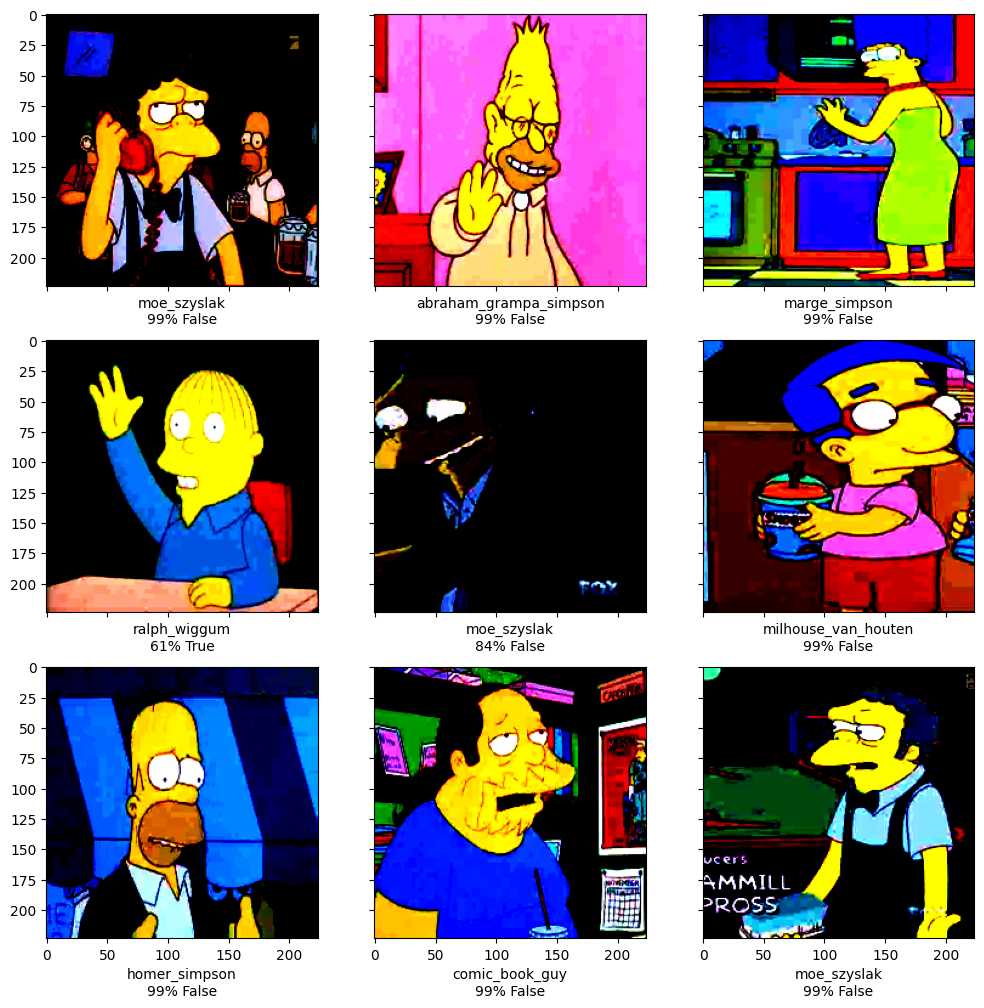

In [150]:
fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = va_dataset[random_characters]
    prob_pred = predict_one_sample(simple_cnn, im_val.unsqueeze(0))
    predicted_proba = int(np.max(prob_pred)*100)
    img_label = le.inverse_transform([label])[0]
    img_label = img_label + '\n' + str(predicted_proba) + '% ' + str(img_label in anamal_labels)

    fig_x.imshow(im_val.data.cpu().numpy().transpose((1, 2, 0)))
    fig_x.set_xlabel(img_label)

Попробуйте найти те классы, которые сеть не смогла расспознать. Изучите данную проблему, это понадобится в дальнейшем.

In [151]:
kop = pd.DataFrame({'name': le.inverse_transform(actual_labels), 'actual': actual_labels, 'predicted':y_pred, 'proba':probs_ims.max(-1)})

In [152]:
left = kop[kop.actual != kop.predicted].groupby('name')['actual'].count()
left.name = 'negatives'
right = pd.Series(le.inverse_transform(val_labels), name='name')
right = right.value_counts()
right.name = 'totally'

In [153]:
merged = pd.merge(left, right, on='name')
merged['recall'] = 1-merged['negatives']/merged['totally']
merged['is_anamal'] = merged.index.isin(anamal_labels).astype(int)

In [154]:
merged.sort_values(['recall', 'totally', 'negatives'], ascending=[1, 0, 0])

,negatives,totally,recall,is_anamal
name,,,,
disco_stu,2,2,0.000000,1
lionel_hutz,1,1,0.000000,1
fat_tony,5,7,0.285714,1
barney_gumble,16,26,0.384615,1
martin_prince,11,18,0.388889,1
gil,4,7,0.428571,1
rainier_wolfcastle,6,11,0.454545,1
groundskeeper_willie,16,30,0.466667,1
professor_john_frink,8,16,0.500000,1


Попробуем что-нибудь зафайнтюнить

ResNet - модель со SkipConnection

In [155]:
from torchvision import models

model = models.resnet18(pretrained=True).to(DEVICE)

/home/alex/Desktop/my_models/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/alex/Desktop/my_models/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [156]:
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(512, len(le.classes_)).to(DEVICE)
for param in model.layer4.parameters():
    param.requires_grad = True

In [157]:
history = train(tr_dataloader, va_dataloader, model=model, epochs=6)

epoch:   0%|          | 0/6 [00:00<?, ?it/s]

loss 0.6881038911512031


epoch:  17%|█▋        | 1/6 [00:46<03:51, 46.37s/it]


Epoch 001 train_loss: 0.6881     val_loss 0.3176 train_acc 0.8292 val_acc 0.9241
loss 0.28110617010443845


epoch:  33%|███▎      | 2/6 [01:30<03:00, 45.16s/it]

...


Epoch 004 train_loss: 0.1286     val_loss 0.2477 train_acc 0.9662 val_acc 0.9396
loss 0.09631961008943492


epoch:  83%|████████▎ | 5/6 [03:42<00:44, 44.13s/it]


Epoch 005 train_loss: 0.0963     val_loss 0.2171 train_acc 0.9751 val_acc 0.9484
loss 0.07973068418509631


epoch: 100%|██████████| 6/6 [04:26<00:00, 44.37s/it]


Epoch 006 train_loss: 0.0797     val_loss 0.2067 train_acc 0.9775 val_acc 0.9561


In [160]:
loss, acc, val_loss, val_acc = zip(*history)

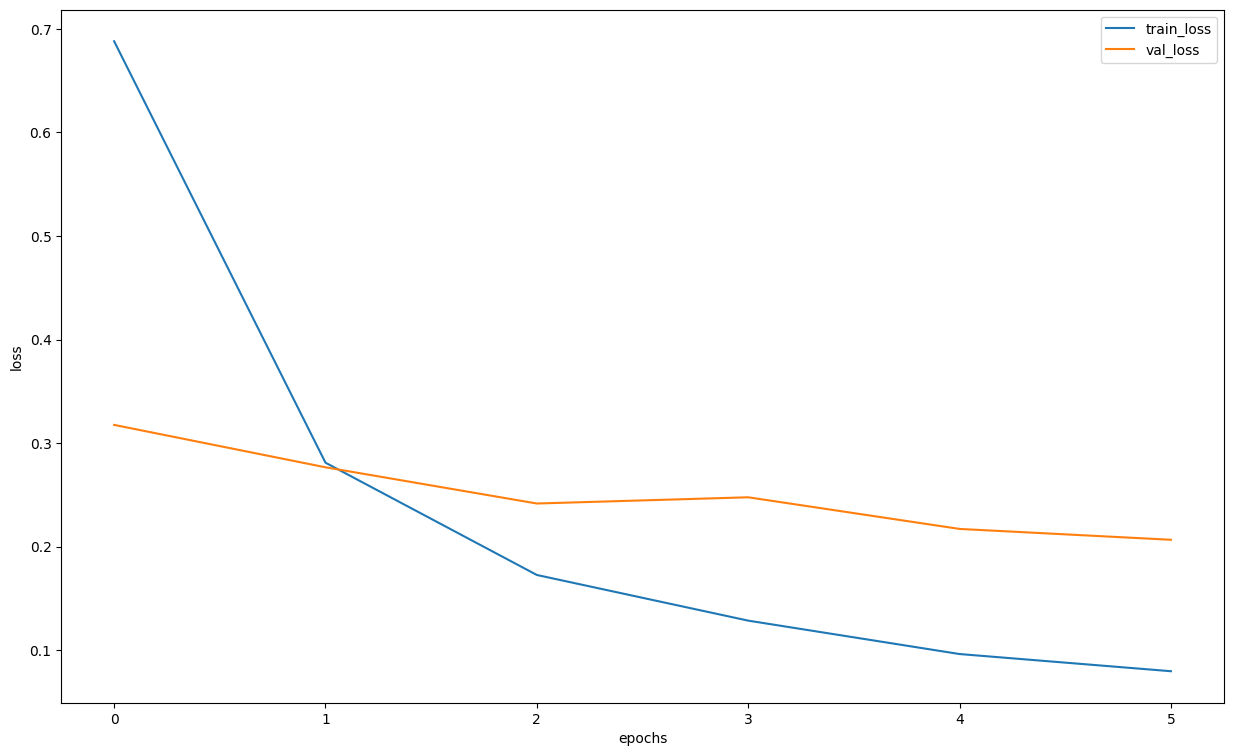

In [161]:
plt.figure(figsize=(15, 9))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

Подсмотрел efficientnet_v2_s на кагле, ща протестим

In [168]:
model = models.efficientnet_v2_s(pretrained=True).to(DEVICE)

/home/alex/Desktop/my_models/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/alex/Desktop/my_models/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [169]:
for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(1280, len(le.classes_)).to(DEVICE)
for param in model.features[6][6:].parameters():
    param.requires_grad = True

In [170]:
optimAdamW = torch.optim.AdamW(model.parameters(), lr=3e-4)
history = train(tr_dataloader, va_dataloader, model=model, epochs=6, opt=optimAdamW)

epoch:   0%|          | 0/6 [00:00<?, ?it/s]

loss 0.8741713365051912


epoch:  17%|█▋        | 1/6 [02:25<12:05, 145.10s/it]


Epoch 001 train_loss: 0.8742     val_loss 0.3282 train_acc 0.7881 val_acc 0.9198
loss 0.3376254613607784


epoch:  33%|███▎      | 2/6 [04:48<09:37, 144.30s/it]

...


Epoch 004 train_loss: 0.1613     val_loss 0.2796 train_acc 0.9553 val_acc 0.9408
loss 0.1334634069960965


epoch:  83%|████████▎ | 5/6 [12:01<02:24, 144.34s/it]


Epoch 005 train_loss: 0.1335     val_loss 0.2452 train_acc 0.9638 val_acc 0.9484
loss 0.10011915979144667


epoch: 100%|██████████| 6/6 [14:25<00:00, 144.30s/it]


Epoch 006 train_loss: 0.1001     val_loss 0.2276 train_acc 0.9721 val_acc 0.9511


In [171]:
loss, acc, val_loss, val_acc = zip(*history)

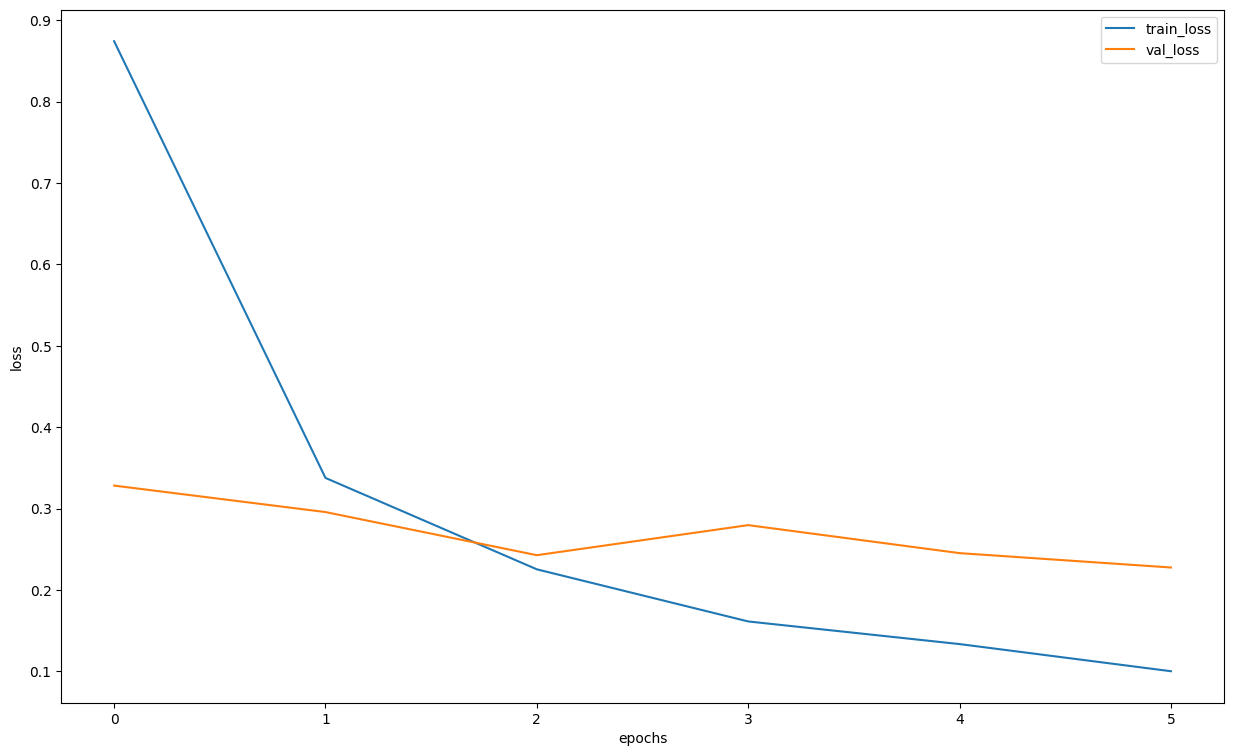

In [172]:
plt.figure(figsize=(15, 9))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.200009].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0678194..2.334449].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5912244].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1165676..2.0570052].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8256302..2.4875176].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.3698888].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.

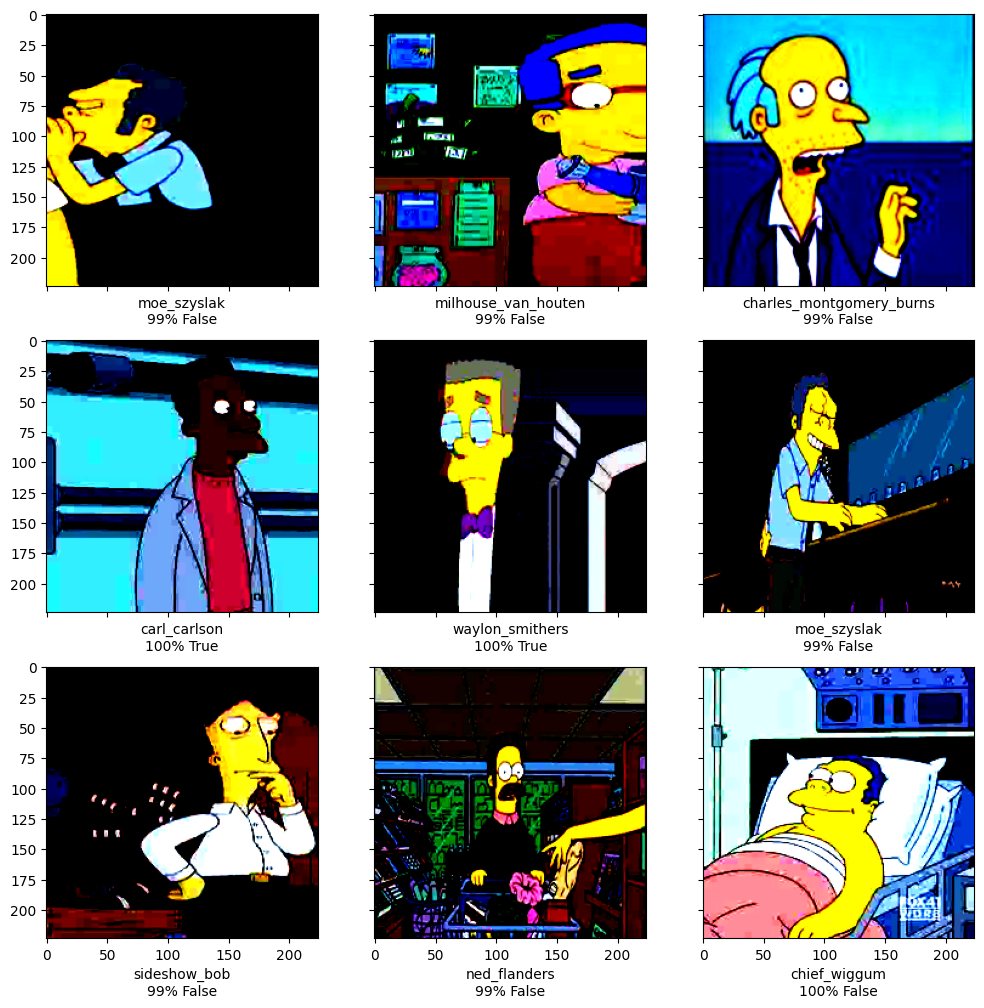

In [176]:
fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = va_dataset[random_characters]
    prob_pred = predict_one_sample(model, im_val.unsqueeze(0))
    predicted_proba = int(np.max(prob_pred)*100)
    img_label = le.inverse_transform([label])[0]
    img_label = img_label + '\n' + str(predicted_proba) + '% ' + str(img_label in anamal_labels)

    fig_x.imshow(im_val.data.cpu().numpy().transpose((1, 2, 0)))
    fig_x.set_xlabel(img_label)

Не получилось добиться качества выше f1=0.95, предпологаю, что недостаточна аугментация редких классов, т.к. уже опробовал разные оптимизаторы (Adam, AdamW), номрировку (BatchNorm), шедуллер (torch.optim.lr_scheduler.StepLR(opt, step_size=1, gamma=0.5)), FineTuning